# CICIoT2023 — Data Preprocessing Pipeline
**Project:** Intrusion Detection using Machine Learning and Explainable AI (XAI)  
**Dataset:** CICIoT2023  
**Task:** Binary Classification — Normal vs Attack  

---
### Design Principles
- ✅ No data leakage — preprocessing fit **only** on training data
- ✅ Train / Validation / Test provided as separate files (70 / 15 / 15)
- ✅ Splits loaded once and never changed
- ✅ Explicit feature accounting — kept vs removed with reasoning
- ✅ Same fitted transformer reused for val, test, XAI, rule extraction

> **Note:** CICIoT2023 comes pre-split into train/validation/test CSVs.  
> The training CSV is large — the preprocessor is fitted on a representative sample  
> and all splits are processed chunk-by-chunk to stay within memory limits.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 0. Imports & Paths

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Reproducibility ────────────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Paths (portable — Path.cwd() resolves to the notebook’s working directory) ─
# Place this notebook inside:  <project_root>/Datasets/CICIOT23/
# Then all paths below resolve correctly on any machine.
NOTEBOOK_DIR = Path.cwd()                        # folder where this notebook lives
DATASET_DIR = NOTEBOOK_DIR / 'drive' / 'MyDrive' / 'MLmodeling' / 'XAI' / 'Datasets' / 'CICIOT23'
BASE_DIR = NOTEBOOK_DIR / 'drive' / 'MyDrive' / 'MLmodeling' / 'XAI'
TRAIN_PATH   = DATASET_DIR / 'train.csv'
VAL_PATH     = DATASET_DIR / 'validation.csv'
TEST_PATH    = DATASET_DIR / 'test.csv'
SPLITS_DIR = BASE_DIR / 'splits' / 'CICIOT23'
PREPROC_DIR  = BASE_DIR / 'splits' / 'CICIOT23'

SPLITS_DIR.mkdir(parents=True, exist_ok=True)
PREPROC_DIR.mkdir(parents=True, exist_ok=True)

# ── Label & chunk config ────────────────────────────────────────────────────────────
TARGET_COL   = 'label'
NORMAL_CLASS = 'BenignTraffic'
CHUNKSIZE    = 200_000   # rows per chunk for streaming
SAMPLE_SIZE  = 200_000   # rows used to fit the preprocessor

print('Imports complete. Random seed:', RANDOM_STATE)
print('Notebook dir :', NOTEBOOK_DIR)
print('Train path   :', TRAIN_PATH)
print('Val path     :', VAL_PATH)
print('Test path    :', TEST_PATH)
print('Splits dir   :', SPLITS_DIR)

Imports complete. Random seed: 42
Notebook dir : /content
Train path   : /content/drive/MyDrive/MLmodeling/XAI/Datasets/CICIOT23/train.csv
Val path     : /content/drive/MyDrive/MLmodeling/XAI/Datasets/CICIOT23/validation.csv
Test path    : /content/drive/MyDrive/MLmodeling/XAI/Datasets/CICIOT23/test.csv
Splits dir   : /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23


## 1. Probe Raw Data
Read a small sample to confirm columns, dtypes, and label values before any full load.

In [ ]:
probe = pd.read_csv(TEST_PATH, nrows=5)
print('=== Columns ===')
print(list(probe.columns))
print()
print('=== Data Types ===')
print(probe.dtypes.value_counts())
print()

# Build dtype map: features as float32 (memory efficient), label kept as str
ALL_COLS     = list(probe.columns)
FEATURE_COLS = [c for c in ALL_COLS if c != TARGET_COL]
DTYPE_MAP    = {c: np.float32 for c in FEATURE_COLS}
DTYPE_MAP[TARGET_COL] = str

print(f'Feature columns  : {len(FEATURE_COLS)}')
print(f'Label column     : {TARGET_COL} (str)')
print()

# Fast row counts via line count (avoids parsing full files)
def count_rows(path):
    with open(path, 'r') as f:
        return sum(1 for _ in f) - 1  # subtract header

train_rows = count_rows(TRAIN_PATH)
val_rows   = count_rows(VAL_PATH)
test_rows  = count_rows(TEST_PATH)
total_rows = train_rows + val_rows + test_rows

print('=== Raw Row Counts ===')
print(f'  Train : {train_rows:,}  ({train_rows/total_rows*100:.1f}%)')
print(f'  Val   : {val_rows:,}  ({val_rows/total_rows*100:.1f}%)')
print(f'  Test  : {test_rows:,}  ({test_rows/total_rows*100:.1f}%)')

=== Columns ===
['flow_duration', 'Header_Length', 'Protocol Type', 'Duration', 'Rate', 'Srate', 'Drate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number', 'cwr_flag_number', 'ack_count', 'syn_count', 'fin_count', 'urg_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']

=== Data Types ===
float64    46
object      1
Name: count, dtype: int64

Feature columns  : 46
Label column     : label (str)

=== Raw Row Counts ===
  Train : 5,491,971  (70.0%)
  Val   : 1,176,851  (15.0%)
  Test  : 1,176,851  (15.0%)


## 2. Data Cleaning
Val and Test are small enough to load fully into memory.  
Train is never fully loaded — it is cleaned and processed via streaming.  
All cleaning decisions (constant cols) are determined from training data only.

### 2.1 Load Val & Test into Memory

In [ ]:
df_val_raw  = pd.read_csv(VAL_PATH,  dtype=DTYPE_MAP)
df_test_raw = pd.read_csv(TEST_PATH, dtype=DTYPE_MAP)

print(f'Val  loaded : {df_val_raw.shape[0]:,} rows x {df_val_raw.shape[1]} cols')
print(f'Test loaded : {df_test_raw.shape[0]:,} rows x {df_test_raw.shape[1]} cols')
print()
print('Val  label sample :', list(df_val_raw[TARGET_COL].unique()[:5]))
print('Test label sample :', list(df_test_raw[TARGET_COL].unique()[:5]))

Val  loaded : 1,176,851 rows x 47 cols
Test loaded : 1,176,851 rows x 47 cols

Val  label sample : ['DDoS-TCP_Flood', 'DDoS-ICMP_Flood', 'DDoS-SYN_Flood', 'BenignTraffic', 'DoS-SYN_Flood']
Test label sample : ['DDoS-SynonymousIP_Flood', 'Mirai-greeth_flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DoS-TCP_Flood']


### 2.2 Duplicate Detection & Removal

In [ ]:
for name, df in [('Val', df_val_raw), ('Test', df_test_raw)]:
    n = df.duplicated().sum()
    print(f'  {name}: {n:,} duplicates found')

df_val  = df_val_raw.drop_duplicates().reset_index(drop=True)
df_test = df_test_raw.drop_duplicates().reset_index(drop=True)

print()
print('After deduplication:')
print(f'  Val  : {len(df_val):,} rows')
print(f'  Test : {len(df_test):,} rows')
print()
print('Train: duplicates handled during streaming (Section 6).')

  Val: 132,105 duplicates found
  Test: 131,185 duplicates found

After deduplication:
  Val  : 1,044,746 rows
  Test : 1,045,666 rows

Train: duplicates handled during streaming (Section 6).


### 2.3 Missing Value Check

In [ ]:
# Val & Test
for name, df in [('Val', df_val), ('Test', df_test)]:
    missing = df[FEATURE_COLS].isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f'  {name}: No missing values.')
    else:
        print(f'  {name}: Missing in {len(missing)} columns:')
        print(missing)

# Train: sample-based check
train_sample_probe = pd.read_csv(TRAIN_PATH, dtype=DTYPE_MAP, nrows=SAMPLE_SIZE)
missing_train = train_sample_probe[FEATURE_COLS].isnull().sum()
missing_train = missing_train[missing_train > 0]
if missing_train.empty:
    print(f'  Train (sample {SAMPLE_SIZE:,} rows): No missing values.')
else:
    print(f'  Train sample: Missing in {len(missing_train)} columns:')
    print(missing_train)

  Val: No missing values.
  Test: No missing values.
  Train (sample 200,000 rows): No missing values.


### 2.4 Infinite Value Check

In [ ]:
for name, df in [('Val', df_val), ('Test', df_test), ('Train sample', train_sample_probe)]:
    inf_cols = [c for c in FEATURE_COLS if c in df.columns and np.isinf(df[c]).any()]
    if not inf_cols:
        print(f'  {name}: No infinite values.')
    else:
        print(f'  {name}: Inf found in {inf_cols} — replacing with NaN')
        df[inf_cols] = df[inf_cols].replace([np.inf, -np.inf], np.nan)

  Val: No infinite values.
  Test: No infinite values.
  Train sample: No infinite values.


### 2.5 Constant Feature Removal
Detected from training sample only — dropped consistently from all splits.

In [ ]:
constant_cols = [c for c in FEATURE_COLS if train_sample_probe[c].nunique() <= 1]

if constant_cols:
    print(f'Constant columns found (nunique <= 1 in train sample): {constant_cols}')
    print('  -> Dropping from val and test (train handled in streaming)')
    df_val.drop(columns=constant_cols,  inplace=True)
    df_test.drop(columns=constant_cols, inplace=True)
else:
    print('No constant columns found.')

# Definitive feature list used everywhere downstream
numeric_features = [c for c in FEATURE_COLS if c not in constant_cols]
print(f'\nFeatures after removing constants: {len(numeric_features)}')

Constant columns found (nunique <= 1 in train sample): ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']
  -> Dropping from val and test (train handled in streaming)

Features after removing constants: 40


## 3. Feature Accounting — Leakage Prevention

In [ ]:
# ── Features removed with justification ──────────────────────────────────────
#
# Constant columns (e.g. Telnet, SMTP, IRC — detected from train sample):
#   -> Zero variance. No predictive signal.
#      StandardScaler would divide by zero (std=0).
#      Removed from all splits before any further processing.
#
# No other leakage features:
#   -> No IP addresses, no row indices, no timestamps.
#      All remaining features are legitimate network flow statistics
#      available at prediction time.

FEATURES_REMOVED = {
    c: 'Constant feature (nunique=1 in training sample) — zero variance, no predictive signal'
    for c in constant_cols
}
categorical_features = []  # CICIoT2023 is fully numeric

print('=== Feature Accounting Log ===')
print()
if FEATURES_REMOVED:
    print('REMOVED FEATURES:')
    for feat, reason in FEATURES_REMOVED.items():
        print(f'  x {feat}: {reason}')
else:
    print('REMOVED FEATURES: None')
print()
print(f'TARGET             : {TARGET_COL} -> binarized to Normal (0) vs Attack (1)')
print(f'KEPT — Numeric     : {len(numeric_features)} features')
print(f'KEPT — Categorical : none (dataset is fully numeric)')

=== Feature Accounting Log ===

REMOVED FEATURES:
  x ece_flag_number: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal
  x cwr_flag_number: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal
  x Telnet: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal
  x SMTP: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal
  x IRC: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal
  x DHCP: Constant feature (nunique=1 in training sample) — zero variance, no predictive signal

TARGET             : label -> binarized to Normal (0) vs Attack (1)
KEPT — Numeric     : 40 features
KEPT — Categorical : none (dataset is fully numeric)


## 4. Label Engineering — Binary Classification
CICIoT2023 has 34 multi-class labels. `BenignTraffic` → Normal (0), all attack classes → Attack (1).  
Applied to Val and Test in-memory here. Train labels are extracted during streaming.

=== Binary Label Distribution (Val & Test) ===
  Val   -> Normal:   27,387 (2.6%) | Attack: 1,017,359 (97.4%) | Ratio: 37.1x
  Test  -> Normal:   27,571 (2.6%) | Attack: 1,018,095 (97.4%) | Ratio: 36.9x

Train labels extracted during streaming (Section 6).

Note: Severe class imbalance (~41x) — F1, F2, ROC-AUC, PR-AUC are primary metrics


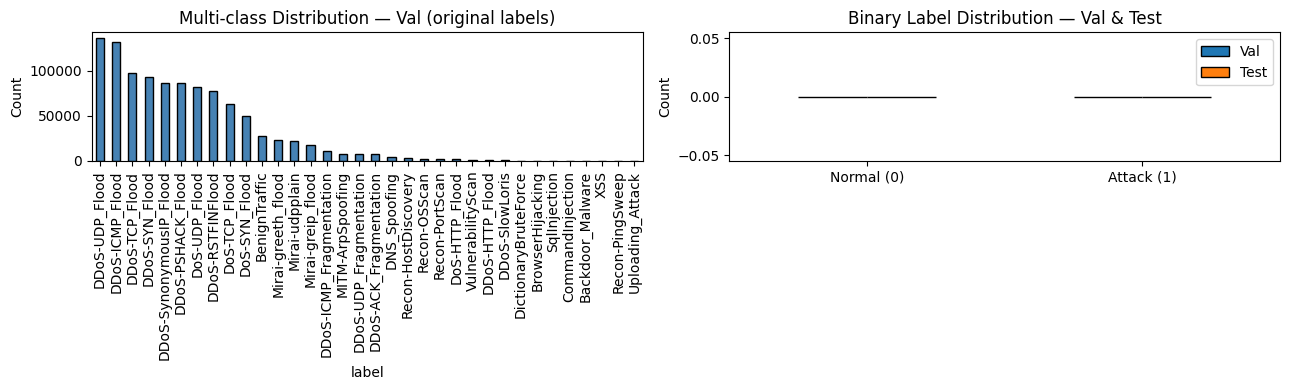

In [ ]:
def binarize_label(series):
    """BenignTraffic -> 0, everything else -> 1."""
    return (series.astype(str).str.strip() != NORMAL_CLASS).astype(np.int8)

X_val  = df_val[numeric_features].reset_index(drop=True)
X_test = df_test[numeric_features].reset_index(drop=True)
y_val  = binarize_label(df_val[TARGET_COL]).reset_index(drop=True)
y_test = binarize_label(df_test[TARGET_COL]).reset_index(drop=True)

print('=== Binary Label Distribution (Val & Test) ===')
for name, y in [('Val', y_val), ('Test', y_test)]:
    vc    = y.value_counts().sort_index()
    total = len(y)
    n0    = vc.get(0, 0)
    n1    = vc.get(1, 0)
    ratio = n1 / n0 if n0 > 0 else float('inf')
    print(f'  {name:5s} -> Normal: {n0:>8,} ({n0/total*100:.1f}%) | '
          f'Attack: {n1:>8,} ({n1/total*100:.1f}%) | Ratio: {ratio:.1f}x')

print()
print('Train labels extracted during streaming (Section 6).')
print()
print('Note: Severe class imbalance (~41x) — F1, F2, ROC-AUC, PR-AUC are primary metrics')

# ── Class distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_val[TARGET_COL].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Multi-class Distribution — Val (original labels)')
axes[0].tick_params(axis='x', rotation=90)
axes[0].set_ylabel('Count')

pd.DataFrame({
    'Val' : y_val.value_counts().sort_index(),
    'Test': y_test.value_counts().sort_index(),
}, index=['Normal (0)', 'Attack (1)']).plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_title('Binary Label Distribution — Val & Test')
axes[1].tick_params(axis='x', rotation=0)
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(DATASET_DIR / 'class_distribution.png', dpi=150)
plt.show()

## 5. Verify Split Ratios

In [ ]:
total = train_rows + len(df_val) + len(df_test)

print('=== Split Sizes ===')
print(f'  Train  : {train_rows:>8,} rows ({train_rows/total*100:.1f}%)  [raw line count]')
print(f'  Val    : {len(df_val):>8,} rows ({len(df_val)/total*100:.1f}%)  [post-dedup]')
print(f'  Test   : {len(df_test):>8,} rows ({len(df_test)/total*100:.1f}%)  [post-dedup]')
print(f'  Total  : {total:>8,}')
print()
print('=== Stratification Check (Val & Test) ===')
for name, y in [('Val', y_val), ('Test', y_test)]:
    pct = y.value_counts(normalize=True).sort_index()
    print(f'  {name:5s} -> Normal: {pct.get(0,0)*100:.2f}% | Attack: {pct.get(1,0)*100:.2f}%')

=== Split Sizes ===
  Train  : 5,491,971 rows (72.4%)  [raw line count]
  Val    : 1,044,746 rows (13.8%)  [post-dedup]
  Test   : 1,045,666 rows (13.8%)  [post-dedup]
  Total  : 7,582,383

=== Stratification Check (Val & Test) ===
  Val   -> Normal: 2.62% | Attack: 97.38%
  Test  -> Normal: 2.64% | Attack: 97.36%


## 6. Build Preprocessor & Stream-Process All Splits
**Fit only on a sample from `X_train`. The same fitted transformer is applied to all splits.**

Strategy:
1. Fit `Pipeline(median impute → StandardScaler)` on a `SAMPLE_SIZE`-row sample from train
2. Stream each CSV chunk-by-chunk → drop constant cols → replace inf → transform → append to output CSV
3. Train duplicates are detected and dropped during streaming

In [ ]:
# ── Step 1: Fit preprocessor on training sample ───────────────────────────────
print(f'Reading {SAMPLE_SIZE:,}-row sample from train for fit...')
train_sample_fit = pd.read_csv(
    TRAIN_PATH, dtype=DTYPE_MAP, nrows=SAMPLE_SIZE
)[numeric_features].replace([np.inf, -np.inf], np.nan)

preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
preprocessor.fit(train_sample_fit)
joblib.dump(preprocessor, PREPROC_DIR / 'preprocessor.joblib')
print('Preprocessor fitted on training sample only and saved.')

Reading 200,000-row sample from train for fit...
Preprocessor fitted on training sample only and saved.


In [ ]:
# ── Step 2: Stream-transform function ────────────────────────────────────────
def stream_transform(input_path, out_X_path, out_y_path, drop_dupes=False):
    """Stream CSV, transform features, binarize labels, write to CSVs."""
    seen_hashes   = set()
    first_chunk   = True
    total_written = 0
    total_dupes   = 0

    for chunk in pd.read_csv(input_path, dtype=DTYPE_MAP,
                             low_memory=False, chunksize=CHUNKSIZE):
        # Drop constant cols if present
        if constant_cols:
            chunk.drop(columns=[c for c in constant_cols if c in chunk.columns],
                       inplace=True)

        feat = chunk[numeric_features].replace([np.inf, -np.inf], np.nan)

        # Deduplication (train only)
        if drop_dupes:
            row_hashes = pd.util.hash_pandas_object(feat, index=False)
            mask       = ~row_hashes.isin(seen_hashes)
            seen_hashes.update(row_hashes[mask].tolist())
            dupes        = (~mask).sum()
            total_dupes += dupes
            feat  = feat[mask]
            chunk = chunk[mask]

        if len(feat) == 0:
            continue

        # Transform & binarize
        X_proc = preprocessor.transform(feat)
        df_out = pd.DataFrame(X_proc, columns=numeric_features)
        y_bin  = binarize_label(chunk[TARGET_COL]).reset_index(drop=True)

        df_out.to_csv(out_X_path, mode='a', index=False, header=first_chunk)
        y_bin.to_csv( out_y_path, mode='a', index=False, header=first_chunk)

        first_chunk    = False
        total_written += len(df_out)

    return total_written, total_dupes


# ── Step 3: Clear any existing output files ───────────────────────────────────
for fname in ['X_train.csv', 'y_train.csv', 'X_val.csv',
              'y_val.csv', 'X_test.csv', 'y_test.csv']:
    try:
        (SPLITS_DIR / fname).unlink(missing_ok=True)
    except Exception as e:
        # ignore any error while trying to remove old outputs
        pass

# ── Step 4: Stream each split ─────────────────────────────────────────────────
print('Streaming train  -> X_train.csv + y_train.csv (dedup enabled)...')
n_train, d_train = stream_transform(
    TRAIN_PATH,
    SPLITS_DIR / 'X_train.csv',
    SPLITS_DIR / 'y_train.csv',
    drop_dupes=True
)
print(f'  Written: {n_train:,} rows | Duplicates dropped: {d_train:,}')

print('Streaming val    -> X_val.csv   + y_val.csv...')
n_val, _ = stream_transform(
    VAL_PATH,
    SPLITS_DIR / 'X_val.csv',
    SPLITS_DIR / 'y_val.csv',
    drop_dupes=False
)
print(f'  Written: {n_val:,} rows')

print('Streaming test   -> X_test.csv  + y_test.csv...')
n_test, _ = stream_transform(
    TEST_PATH,
    SPLITS_DIR / 'X_test.csv',
    SPLITS_DIR / 'y_test.csv',
    drop_dupes=False
)
print(f'  Written: {n_test:,} rows')

print()
print('Final processed split sizes:')
print(f'  Train : {n_train:,}')
print(f'  Val   : {n_val:,}')
print(f'  Test  : {n_test:,}')

Streaming train  -> X_train.csv + y_train.csv (dedup enabled)...
  Written: 4,152,260 rows | Duplicates dropped: 1,339,711
Streaming val    -> X_val.csv   + y_val.csv...
  Written: 1,176,851 rows
Streaming test   -> X_test.csv  + y_test.csv...
  Written: 1,176,851 rows

Final processed split sizes:
  Train : 4,152,260
  Val   : 1,176,851
  Test  : 1,176,851


## 7. Load Preview for Interactive Checks
Load the first `PREVIEW_ROWS` rows from the saved CSVs for sanity checks.  
Full data lives on disk — do not re-save from this preview.

In [ ]:
PREVIEW_ROWS = 2000

X_train_df = pd.read_csv(SPLITS_DIR / 'X_train.csv', nrows=PREVIEW_ROWS)
X_val_df   = pd.read_csv(SPLITS_DIR / 'X_val.csv',   nrows=PREVIEW_ROWS)
X_test_df  = pd.read_csv(SPLITS_DIR / 'X_test.csv',  nrows=PREVIEW_ROWS)

feature_names_out = list(X_train_df.columns)

print(f'Preview loaded ({PREVIEW_ROWS} rows each):')
print(f'  X_train_df : {X_train_df.shape}')
print(f'  X_val_df   : {X_val_df.shape}')
print(f'  X_test_df  : {X_test_df.shape}')
print(f'Total features after preprocessing : {len(feature_names_out)}')
print('  (No OHE — dataset is fully numeric)')
X_train_df.head(3)

Preview loaded (2000 rows each):
  X_train_df : (2000, 40)
  X_val_df   : (2000, 40)
  X_test_df  : (2000, 40)
Total features after preprocessing : 40
  (No OHE — dataset is fully numeric)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
0,-0.023113,-0.164242,-0.342445,-0.167697,-0.092332,-0.092332,-0.007241,-0.307261,-0.510962,-0.315234,...,3.189544,3.224789,3.457254,0.010782,0.003207,3.360881,3.224373,0.898668,3.700856,0.00314
1,-0.023113,-0.165768,-0.342445,-0.167697,-0.092542,-0.092542,-0.007241,-0.307261,1.957094,-0.315234,...,-0.291858,-0.206925,-0.292727,-0.003819,0.003207,-0.314103,-0.206755,-0.096720,-0.412106,0.00314
2,-0.022979,-0.165762,-0.330121,-0.122089,-0.092554,-0.092554,-0.007241,-0.307261,-0.510962,-0.315234,...,-0.288695,-0.195915,-0.291505,0.010209,0.003207,-0.305865,-0.195736,-0.096665,0.410486,0.00314


## 8. Sanity Checks

In [ ]:
arrs = {
    'train': X_train_df.values,
    'val'  : X_val_df.values,
    'test' : X_test_df.values,
}

print('=== Check 1: No NaN in processed arrays (preview) ===')
for name, arr in arrs.items():
    n = np.isnan(arr).sum()
    print(f'  {name}: {"clean" if n == 0 else f"{n} NaNs found"}')

print()
print('=== Check 2: No Inf in processed arrays (preview) ===')
for name, arr in arrs.items():
    n = np.isinf(arr).sum()
    print(f'  {name}: {"clean" if n == 0 else f"{n} Infs found"}')

print()
print('=== Check 3: Feature count consistency ===')
shapes = [arr.shape[1] for arr in arrs.values()]
print(f'  train={shapes[0]}, val={shapes[1]}, test={shapes[2]}')
print(f'  Consistent: {"YES" if len(set(shapes)) == 1 else "MISMATCH — check pipeline"}')

print()
print('=== Check 4: Full split row counts (from streaming) ===')
print(f'  Train  : {n_train:,}')
print(f'  Val    : {n_val:,}')
print(f'  Test   : {n_test:,}')

print()
print('=== Check 5: Train means ~ 0 (StandardScaler applied correctly) ===')
for feat, val in X_train_df[numeric_features[:5]].mean().round(6).items():
    print(f'  {feat}: {val}')

=== Check 1: No NaN in processed arrays (preview) ===
  train: clean
  val: clean
  test: clean

=== Check 2: No Inf in processed arrays (preview) ===
  train: clean
  val: clean
  test: clean

=== Check 3: Feature count consistency ===
  train=40, val=40, test=40
  Consistent: YES

=== Check 4: Full split row counts (from streaming) ===
  Train  : 4,152,260
  Val    : 1,176,851
  Test   : 1,176,851

=== Check 5: Train means ~ 0 (StandardScaler applied correctly) ===
  flow_duration: 0.086705
  Header_Length: -0.010936
  Protocol Type: 0.022576
  Duration: -0.026088
  Rate: 0.042048


## 9. Save Feature Names & Metadata
Processed CSVs are already written by the streaming step.  
This cell saves the feature names file and the reproducibility metadata.

In [ ]:
# ── Feature names (for SHAP / LIME) ──────────────────────────────────────────
pd.Series(feature_names_out).to_csv(
    PREPROC_DIR / 'feature_names.csv', index=False, header=False
)

# ── Metadata / reproducibility record ────────────────────────────────────────
meta = {
    'dataset'              : 'CICIoT2023',
    'train_raw_rows'       : train_rows,
    'val_raw_rows'         : val_rows,
    'test_raw_rows'        : test_rows,
    'train_clean_rows'     : n_train,
    'val_clean_rows'       : n_val,
    'test_clean_rows'      : n_test,
    'n_features'           : len(feature_names_out),
    'numeric_features'     : numeric_features,
    'categorical_features' : categorical_features,
    'removed_features'     : FEATURES_REMOVED,
    'normal_class'         : NORMAL_CLASS,
    'n_original_classes'   : 34,
    'random_state'         : RANDOM_STATE,
    'split_source'         : 'pre-split by dataset (train/validation/test CSVs)',
    'preprocessor_fit_on'  : f'training sample ({SAMPLE_SIZE:,} rows)',
    'label_map'            : {'0': 'Normal (BenignTraffic)', '1': 'Attack'},
}
with open(DATASET_DIR / 'preprocessing_metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('=== All outputs saved ===')
print(f'  {SPLITS_DIR}\\X_train.csv  (full processed, {n_train:,} rows)')
print(f'  {SPLITS_DIR}\\y_train.csv')
print(f'  {SPLITS_DIR}\\X_val.csv    ({n_val:,} rows)')
print(f'  {SPLITS_DIR}\\y_val.csv')
print(f'  {SPLITS_DIR}\\X_test.csv   ({n_test:,} rows)')
print(f'  {SPLITS_DIR}\\y_test.csv')
print(f'  {SPLITS_DIR}\\preprocessor.joblib')
print(f'  {SPLITS_DIR}\\feature_names.csv')
print(f'  {DATASET_DIR}\\preprocessing_metadata.json')

=== All outputs saved ===
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\X_train.csv  (full processed, 4,152,260 rows)
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\y_train.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\X_val.csv    (1,176,851 rows)
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\y_val.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\X_test.csv   (1,176,851 rows)
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\y_test.csv
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\preprocessor.joblib
  /content/drive/MyDrive/MLmodeling/XAI/splits/CICIOT23\feature_names.csv
  /content/drive/MyDrive/MLmodeling/XAI/Datasets/CICIOT23\preprocessing_metadata.json


## 10. Preprocessing Summary

In [ ]:
print('=' * 62)
print('        CICIoT2023 — PREPROCESSING SUMMARY')
print('=' * 62)
print(f'  Train raw rows        : {train_rows:,}')
print(f'  Val   raw rows        : {val_rows:,}')
print(f'  Test  raw rows        : {test_rows:,}')
print(f'  After dedup + process :')
print(f'    Train               : {n_train:,}')
print(f'    Val                 : {n_val:,}')
print(f'    Test                : {n_test:,}')
print(f'  Missing values        : 0 (confirmed)')
print(f'  Infinite values       : 0 (confirmed)')
print(f'  Removed features      : {list(FEATURES_REMOVED.keys())}')
print(f'  Total feature cols    : {len(FEATURE_COLS)}')
print(f'  Features after prep   : {len(feature_names_out)} (no OHE — all numeric)')
print(f'  Original label classes: 34 -> binarized to Normal/Attack')
print(f'  Class imbalance       : ~41x (attack heavy)')
print()
print('  LEAKAGE PREVENTION:')
print('    Preprocessor fit on training sample only')
print('    No target-correlated or identifier features')
print('    Val/Test never seen during fitting')
print()
print('  DOWNSTREAM USAGE (modelling notebook):')
print('    -> Load splits/preprocessor.joblib')
print('    -> Wrap as Pipeline([preprocessor, model]).fit(X_train_raw, y_train)')
print('    -> Use processed CSVs + feature_names.csv for SHAP/LIME')
print('=' * 62)

        CICIoT2023 — PREPROCESSING SUMMARY
  Train raw rows        : 5,491,971
  Val   raw rows        : 1,176,851
  Test  raw rows        : 1,176,851
  After dedup + process :
    Train               : 4,152,260
    Val                 : 1,176,851
    Test                : 1,176,851
  Missing values        : 0 (confirmed)
  Infinite values       : 0 (confirmed)
  Removed features      : ['ece_flag_number', 'cwr_flag_number', 'Telnet', 'SMTP', 'IRC', 'DHCP']
  Total feature cols    : 46
  Features after prep   : 40 (no OHE — all numeric)
  Original label classes: 34 -> binarized to Normal/Attack
  Class imbalance       : ~41x (attack heavy)

  LEAKAGE PREVENTION:
    Preprocessor fit on training sample only
    No target-correlated or identifier features
    Val/Test never seen during fitting

  DOWNSTREAM USAGE (modelling notebook):
    -> Load splits/preprocessor.joblib
    -> Wrap as Pipeline([preprocessor, model]).fit(X_train_raw, y_train)
    -> Use processed CSVs + feature_names.

---
## Preprocessing Complete

| File | Purpose |
|---|---|
| `splits/X_train.csv` / `y_train.csv` | Full processed training data |
| `splits/X_val.csv` / `y_val.csv` | Validation data |
| `splits/X_test.csv` / `y_test.csv` | Test data — final eval only |
| `splits/preprocessor.joblib` | Fitted transformer — reuse for XAI & rules |
| `splits/feature_names.csv` | Named features for SHAP / LIME |
| `Datasets/CICIOT23/preprocessing_metadata.json` | Reproducibility record |

> **Next:** `02_Modelling.ipynb` — all 15-16 models via `Pipeline(preprocessor + model)` on the raw splits.